In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

import shap

In [2]:
transactions = pd.read_csv(
    "data/processed/clean_transactions.csv"
)

transactions["invoicedate"] = pd.to_datetime(
    transactions["invoicedate"]
)

transactions.head()

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,is_cancelled,is_return,revenue,year,month,month_name,day,day_name,hour,quarter,week
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,False,False,83.4,2009,12,December,1,Tuesday,7,4,49
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False,False,81.0,2009,12,December,1,Tuesday,7,4,49
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False,False,81.0,2009,12,December,1,Tuesday,7,4,49
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,False,False,100.8,2009,12,December,1,Tuesday,7,4,49
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,False,False,30.0,2009,12,December,1,Tuesday,7,4,49


In [3]:
snapshot_date = transactions["invoicedate"].max()

cutoff_date = snapshot_date - pd.DateOffset(months=3)

historical = transactions[
    transactions["invoicedate"] <= cutoff_date
].copy()

future = transactions[
    transactions["invoicedate"] > cutoff_date
].copy()

print("Historical :", historical.shape)

print("Future :", future.shape)

Historical : (635177, 19)
Future : (162708, 19)


In [ ]:
historical_sales = historical[
    (~historical["is_return"])
    &
    (~historical["is_cancelled"])
].copy()

snapshot = historical_sales["invoicedate"].max()

customer_df = pd.DataFrame({

    "customer_id":
    historical_sales["customer_id"].unique()

})


,customer_id
0,13085
1,13078
2,15362
3,18102
4,12682


In [5]:
rfm = (
    historical_sales
    .groupby("customer_id")
    .agg(
        recency=(
            "invoicedate",
            lambda x: (snapshot - x.max()).days
        ),
        frequency=("invoice","nunique"),
        monetary=("revenue","sum")
    )
    .reset_index()
)

customer_df = customer_df.merge(
    rfm,
    on="customer_id",
    how="left"
)

spending = (
    historical_sales
    .groupby("customer_id")
    .agg(
        avg_order_value=("revenue","mean"),
        total_orders=("invoice","nunique"),
        total_revenue=("revenue","sum"),
        total_products=("quantity","sum")
    )
    .reset_index()
)

spending["avg_revenue_per_product"] = np.where(
    spending["total_products"] > 0,
    spending["total_revenue"] /
    spending["total_products"],
    0
)

customer_df = customer_df.merge(
    spending[
        [
            "customer_id",
            "avg_order_value",
            "avg_revenue_per_product",
            "total_products"
        ]
    ],
    on="customer_id",
    how="left"
)


product = (
    historical_sales
    .groupby("customer_id")
    .agg(
        unique_products=("stockcode", "nunique")
    )
    .reset_index()
)

customer_df = customer_df.merge(
    product,
    on="customer_id",
    how="left"
)

customer_df["avg_basket_size"] = np.where(
    customer_df["frequency"] > 0,
    customer_df["total_products"] /
    customer_df["frequency"],
    0
)

customer_df["product_diversity"] = np.where(
    customer_df["total_products"] > 0,
    customer_df["unique_products"] /
    customer_df["total_products"],
    0
)



lifetime = (
    historical_sales
    .groupby("customer_id")
    .agg(
        first_purchase=("invoicedate", "min"),
        last_purchase=("invoicedate", "max")
    )
    .reset_index()
)

lifetime["customer_lifetime_days"] = (
    lifetime["last_purchase"] -
    lifetime["first_purchase"]
).dt.days

lifetime["days_since_first_purchase"] = (
    snapshot -
    lifetime["first_purchase"]
).dt.days

customer_df = customer_df.merge(
    lifetime[
        [
            "customer_id",
            "customer_lifetime_days",
            "days_since_first_purchase"
        ]
    ],
    on="customer_id",
    how="left"
)




sales_sorted = (
    historical_sales
    .sort_values(
        ["customer_id", "invoicedate"]
    )
)

sales_sorted["purchase_gap"] = (
    sales_sorted
    .groupby("customer_id")["invoicedate"]
    .diff()
    .dt.days
)

purchase_stats = (
    sales_sorted
    .groupby("customer_id")
    .agg(
        avg_purchase_interval=("purchase_gap", "mean"),
        purchase_consistency=("purchase_gap", "std")
    )
    .reset_index()
)

customer_df = customer_df.merge(
    purchase_stats,
    on="customer_id",
    how="left"
)

customer_df["avg_purchase_interval"] = (
    customer_df["avg_purchase_interval"].fillna(0)
)

customer_df["purchase_consistency"] = (
    customer_df["purchase_consistency"].fillna(0)
)


customer_df["purchase_frequency_per_month"] = np.where(
    customer_df["customer_lifetime_days"] > 0,
    customer_df["frequency"] /
    (customer_df["customer_lifetime_days"] / 30),
    customer_df["frequency"]
)

active_months = (
    historical_sales
    .assign(
        year_month=historical_sales["invoicedate"].dt.to_period("M")
    )
    .groupby("customer_id")["year_month"]
    .nunique()
    .reset_index(name="active_months")
)

customer_df = customer_df.merge(
    active_months,
    on="customer_id",
    how="left"
)



return_features = (
    historical
    .groupby("customer_id")
    .agg(
        total_transactions=("invoice", "count"),
        total_returns=("is_return", "sum"),
        total_cancelled=("is_cancelled", "sum")
    )
    .reset_index()
)

return_features["return_rate"] = (
    return_features["total_returns"] /
    return_features["total_transactions"]
)

return_features["cancellation_rate"] = (
    return_features["total_cancelled"] /
    return_features["total_transactions"]
)

customer_df = customer_df.merge(
    return_features[
        [
            "customer_id",
            "return_rate",
            "cancellation_rate"
        ]
    ],
    on="customer_id",
    how="left"
)


In [6]:
future_sales = future[
    (~future["is_return"])
    &
    (~future["is_cancelled"])
].copy()

clv = (
    future_sales
    .groupby("customer_id")
    .agg(
        future_clv=("revenue", "sum")
    )
    .reset_index()
)

customer_df = customer_df.merge(
    clv,
    on="customer_id",
    how="left"
)

customer_df["future_clv"] = (
    customer_df["future_clv"]
    .fillna(0)
)

In [7]:
customer_df.fillna(0, inplace=True)
customer_df.to_csv(
    "data/processed/clv_dataset.csv",
    index=False
)

print("CLV dataset saved successfully!")


CLV dataset saved successfully!


In [9]:
customer_df["future_clv_log"] = np.log1p(
    customer_df["future_clv"]
)

In [10]:
df = customer_df.copy()

X = df.drop(
    columns=[
        "customer_id",
        "future_clv",
        "future_clv_log"
    ]
)

y = df["future_clv_log"]

print(X.shape)
print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(5281, 17)
(5281,)
(4224, 17)
(1057, 17)


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [12]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(X_test)

In [13]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

xgb_pred = xgb.predict(X_test)

In [14]:
def evaluate_regression(name, y_true, pred):

    rmse = np.sqrt(mean_squared_error(y_true, pred))

    print("=" * 60)
    print(name)
    print("=" * 60)

    print("MAE :", mean_absolute_error(y_true, pred))
    print("RMSE:", rmse)
    print("R²  :", r2_score(y_true, pred))
    

evaluate_regression(
    "Random Forest",
    y_test,
    rf_pred
)

evaluate_regression(
    "XGBoost",
    y_test,
    xgb_pred
)

Random Forest
MAE : 2.1095882034340927
RMSE: 2.575351183122672
R²  : 0.36487971576196454
XGBoost
MAE : 2.1002469337778567
RMSE: 2.5942835000292734
R²  : 0.3555074049032011


In [16]:
comparison = pd.DataFrame({

    "Model":[
        
        "Random Forest",
        "XGBoost"
    ],

    "MAE":[
       
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, xgb_pred)
    ],

    "RMSE":[
        
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, xgb_pred))
    ],

    "R2":[
       
        r2_score(y_test, rf_pred),
        r2_score(y_test, xgb_pred)
    ]

})

comparison.sort_values(
    "R2",
    ascending=False
)

,Model,MAE,RMSE,R2
0,Random Forest,2.109588,2.575351,0.364880
1,XGBoost,2.100247,2.594284,0.355507


In [17]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf.feature_importances_

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
0,recency,0.260942
2,monetary,0.213285
5,total_products,0.072060
6,unique_products,0.046762
1,frequency,0.044322
13,purchase_frequency_per_month,0.042741
3,avg_order_value,0.042295
4,avg_revenue_per_product,0.040310
12,purchase_consistency,0.039405
7,avg_basket_size,0.038047


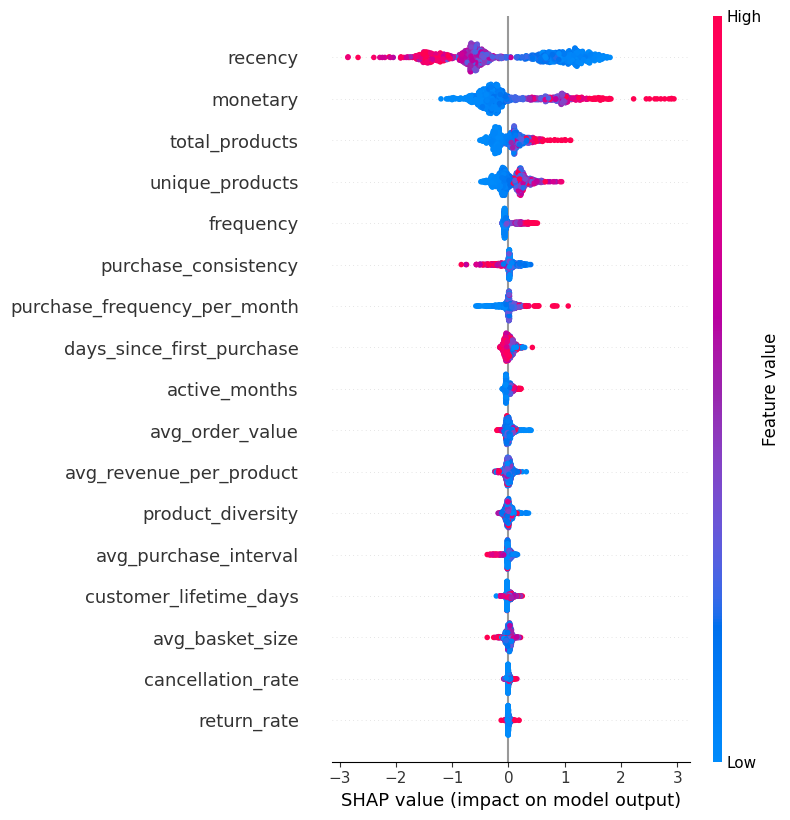

In [18]:
explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="dot"
)


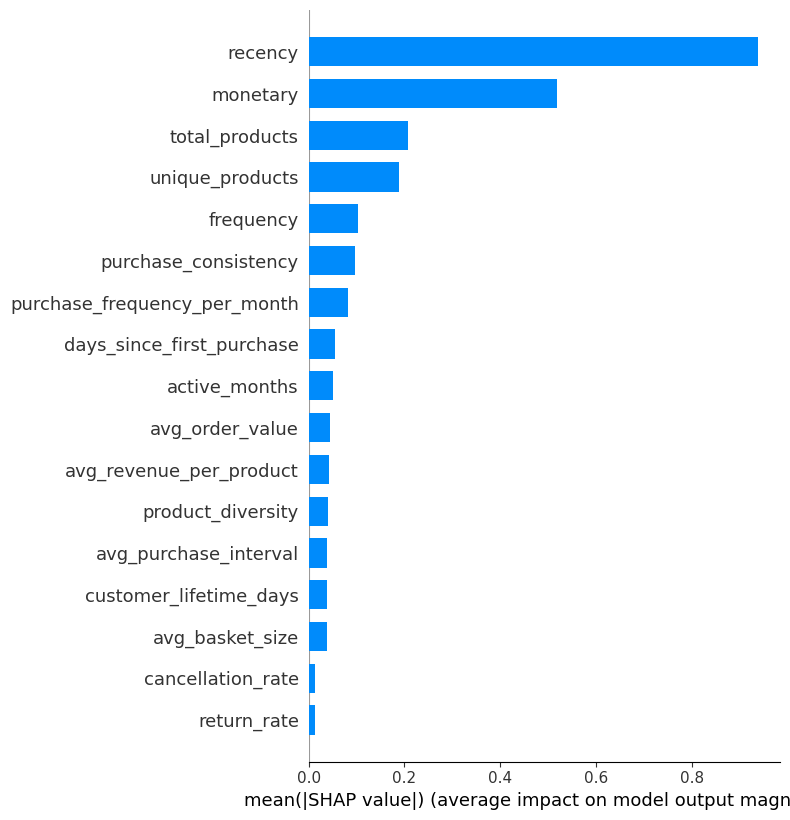

In [19]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

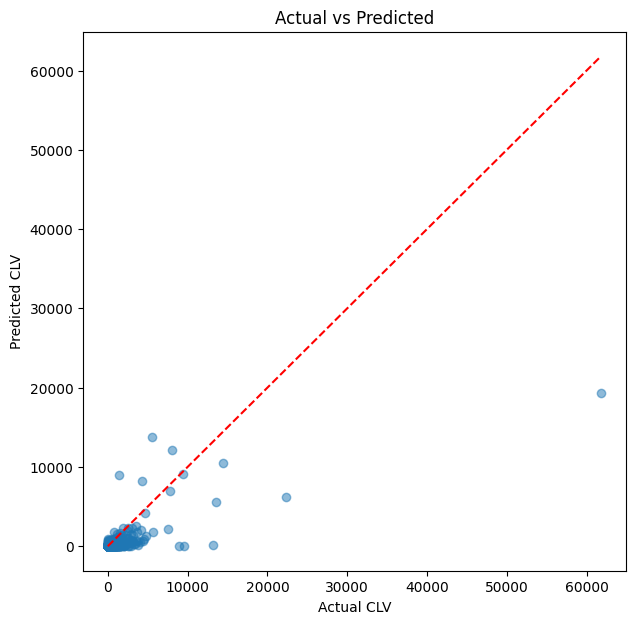

In [20]:
actual = np.expm1(y_test)

predicted = np.expm1(rf_pred)

plt.figure(figsize=(7,7))

plt.scatter(
    actual,
    predicted,
    alpha=0.5
)

plt.xlabel("Actual CLV")

plt.ylabel("Predicted CLV")

plt.title("Actual vs Predicted")

plt.plot(
    [0, actual.max()],
    [0, actual.max()],
    "r--"
)

plt.show()

In [21]:
import joblib

joblib.dump(
    rf,
    "models/clv_random_forest.pkl"
)

print("Model Saved")

Model Saved


In [22]:
# Convert back to original CLV values

actual_clv = np.expm1(y_test)

predicted_clv = np.expm1(rf_pred)


print("="*60)
print("Random Forest CLV Evaluation (Original Scale)")
print("="*60)

print(f"MAE  : {mean_absolute_error(actual_clv, predicted_clv):,.2f}")

print(f"RMSE : {np.sqrt(mean_squared_error(actual_clv, predicted_clv)):,.2f}")

print(f"R²   : {r2_score(actual_clv, predicted_clv):.4f}")


print("\nSample Predictions\n")

results = pd.DataFrame({
    "Actual CLV": actual_clv,
    "Predicted CLV": predicted_clv
})

display(results.head(15))

Random Forest CLV Evaluation (Original Scale)
MAE  : 398.95
RMSE : 1,697.11
R²   : 0.4682

Sample Predictions



,Actual CLV,Predicted CLV
8,0.00,3.007220
1580,0.00,11.150348
544,7992.71,12074.645465
5201,0.00,21.655848
3942,599.04,4.784558
2312,0.00,2.688469
3407,86.90,2.557054
1503,1049.61,259.822247
167,0.00,3.679501
346,515.10,6.180251


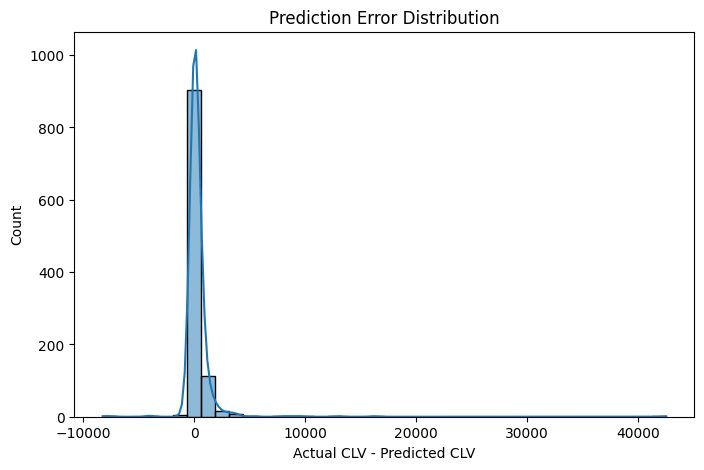

In [23]:
errors = actual_clv - predicted_clv

plt.figure(figsize=(8,5))

sns.histplot(
    errors,
    bins=40,
    kde=True
)

plt.title("Prediction Error Distribution")
plt.xlabel("Actual CLV - Predicted CLV")

plt.show()

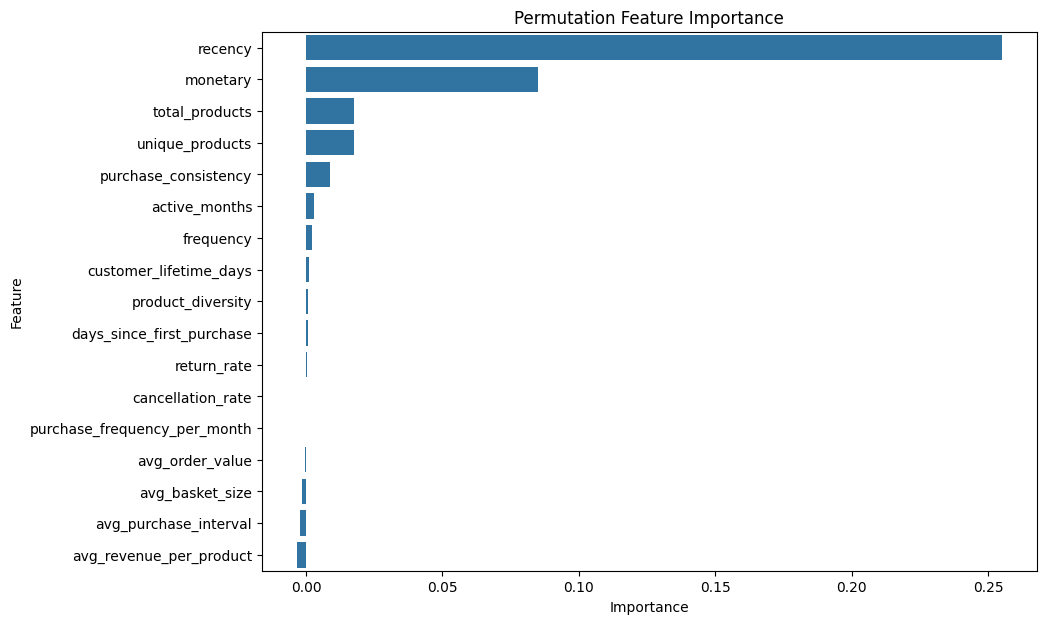

,Feature,Importance
0,recency,0.255021
2,monetary,0.084905
5,total_products,0.017502
6,unique_products,0.017495
12,purchase_consistency,0.008911
14,active_months,0.002774
1,frequency,0.002029
9,customer_lifetime_days,0.001017
8,product_diversity,0.000570
10,days_since_first_purchase,0.000544


In [24]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2"
)

perm_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm.importances_mean
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10,7))

sns.barplot(
    data=perm_importance,
    x="Importance",
    y="Feature"
)

plt.title("Permutation Feature Importance")

plt.show()

perm_importance

In [25]:
customer_predictions = X_test.copy()

customer_predictions["customer_id"] = (
    df.loc[X_test.index, "customer_id"].values
)

customer_predictions["Actual_CLV"] = np.expm1(y_test)

customer_predictions["Predicted_CLV"] = np.expm1(rf_pred)

customer_predictions = customer_predictions[
    [
        "customer_id",
        "Actual_CLV",
        "Predicted_CLV"
    ]
]

customer_predictions.head()

,customer_id,Actual_CLV,Predicted_CLV
8,12636,0.00,3.007220
1580,18218,0.00,11.150348
544,13798,7992.71,12074.645465
5201,12729,0.00,21.655848
3942,17951,599.04,4.784558


In [26]:
customer_predictions["CLV_Category"] = pd.qcut(
    customer_predictions["Predicted_CLV"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "VIP"
    ]
)

customer_predictions.head()

,customer_id,Actual_CLV,Predicted_CLV,CLV_Category
8,12636,0.00,3.007220,Medium
1580,18218,0.00,11.150348,High
544,13798,7992.71,12074.645465,VIP
5201,12729,0.00,21.655848,High
3942,17951,599.04,4.784558,Medium


In [30]:
customer_predictions["CLV_Category"] = pd.cut(
    customer_predictions["Predicted_CLV"],
    bins=[
        -1,
        100,
        500,
        2000,
        np.inf
    ],
    labels=[
        "Low",
        "Medium",
        "High",
        "VIP"
    ]
)

customer_predictions["CLV_Category"].value_counts()

CLV_Category
Low       844
Medium    143
High       53
VIP        17
Name: count, dtype: int64

In [29]:
top_customers = (
    customer_predictions
    .sort_values(
        "Predicted_CLV",
        ascending=False
    )
)

top_customers.head(20)


customer_predictions.to_csv(
    "data/processed/clv_predictions.csv",
    index=False
)

print("CLV predictions saved successfully.")

CLV predictions saved successfully.
